# Analyse du risque de maladie cardiaque
## Analyse exploratoire orientée métier et régression logistique interprétable

### Objectif du projet

L’objectif de cette analyse est d’identifier les facteurs les plus associés à la présence d’une maladie cardiaque et de construire un modèle simple, lisible et exploitable dans une logique d’aide à la décision.

### Contexte métier

Dans un contexte de dépistage, l’enjeu principal n’est pas seulement la performance globale du modèle, mais sa capacité à limiter les faux négatifs. Ne pas détecter un patient à risque peut en effet retarder sa prise en charge et avoir un impact clinique important.

Le projet privilégie donc une approche rigoureuse dans l’analyse exploratoire, prudente dans l’interprétation, et orientée vers un modèle explicable plutôt qu’une logique de complexité technique.

### Démarche

Le notebook est structuré en deux temps :
1. une analyse exploratoire pour comprendre la structure du jeu de données et repérer les variables les plus informatives ;
2. une modélisation par régression logistique afin de conserver un bon niveau d’interprétabilité.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

## 1. Chargement des données

Le dataset est importé puis affiché pour vérifier sa structure générale.

In [2]:
import kagglehub

path = kagglehub.dataset_download("rishidamarla/heart-disease-prediction")
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
df = pd.read_csv(os.path.join(path, csv_files[0]))

df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.400,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.600,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.300,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.200,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.200,1,1,3,Absence


## 2. Vue d’ensemble du jeu de données

Cette première lecture permet de :
- vérifier la taille du jeu de données ;
- identifier les types de variables ;
- repérer la variable cible ;
- préparer l’audit qualité.

In [3]:
overview_df = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "missing": df.isna().sum()
}).sort_values(by=["missing", "n_unique"], ascending=[False, False])

overview_df

,dtype,n_unique,missing
Cholesterol,int64,144,0
Max HR,int64,90,0
BP,int64,47,0
Age,int64,41,0
ST depression,float64,39,0
Chest pain type,int64,4,0
Number of vessels fluro,int64,4,0
EKG results,int64,3,0
Slope of ST,int64,3,0
Thallium,int64,3,0


In [4]:
print(f"Shape: {df.shape}")
display(df.head())
df.info()

Shape: (270, 14)


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.400,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.600,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.300,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.200,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.200,1,1,3,Absence


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

La première inspection permet d’identifier la variable cible (Heart Disease), la nature des variables disponibles et la coexistence de variables numériques (Age, BP, Cholesterol, Max HR, ST depression) et catégorielles (Sex , Chest pain type, FBS over 120, EKG results, Exercise angina, Slope of ST, Number of vessels fluro, Thallium).

## 3. Préparation de la variable cible

La variable cible Heart Disease est convertie en variable binaire :
- 0 = absence de maladie ;
- 1 = présence de maladie.

Cette harmonisation simplifie la suite de l’analyse.

In [5]:
df_model = df.copy()

df_model["HeartDisease"] = (
    df_model["Heart Disease"]
    .map({"Absence": 0, "Presence": 1})
    .astype(int)
)

df_model = df_model.drop(columns=["Heart Disease"])

display(df_model["HeartDisease"].value_counts().rename_axis("HeartDisease").reset_index(name="count"))
df_model.head()

,HeartDisease,count
0,0,150
1,1,120


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,HeartDisease
0,70,1,4,130,322,0,2,109,0,2.400,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.600,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.300,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.200,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.200,1,1,3,0


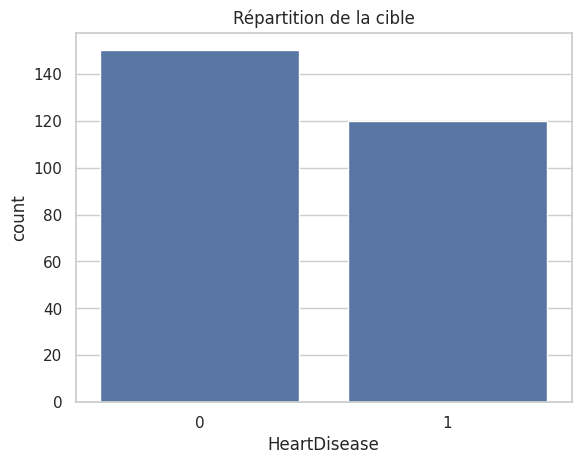

In [6]:
sns.countplot(data=df_model, x="HeartDisease")
plt.title("Répartition de la cible")
plt.show()

## 4. Audit qualité des données

Il faut vérifier :
- les valeurs manquantes ;
- les doublons ;
- les distributions inhabituelles ;
- les modalités des variables discrètes ;
- les valeurs potentiellement aberrantes.

In [7]:
# Valeurs manquantes
missing_df = (
    df_model.isna()
    .sum()
    .rename("missing_count")
    .reset_index()
    .rename(columns={"index": "feature"})
    .sort_values("missing_count", ascending=False)
)

display(missing_df)

# Doublons
n_duplicates = df_model.duplicated().sum()
print(f"Nombre de doublons : {n_duplicates}")

,feature,missing_count
0,Age,0
1,Sex,0
2,Chest pain type,0
3,BP,0
4,Cholesterol,0
5,FBS over 120,0
6,EKG results,0
7,Max HR,0
8,Exercise angina,0
9,ST depression,0


Nombre de doublons : 0


In [8]:
numeric_features = ["Age", "BP", "Cholesterol", "Max HR", "ST depression"]
categorical_features = ["Sex", "Chest pain type", "FBS over 120", "EKG results", "Exercise angina", "Slope of ST",
                        "Number of vessels fluro", "Thallium"]

summary_numeric = df_model[numeric_features].describe().T
summary_numeric["missing"] = df_model[numeric_features].isna().sum()
summary_numeric

,count,mean,std,min,25%,50%,75%,max,missing
Age,270.000,54.433,9.109,29.000,48.000,55.000,61.000,77.000,0
BP,270.000,131.344,17.862,94.000,120.000,130.000,140.000,200.000,0
Cholesterol,270.000,249.659,51.686,126.000,213.000,245.000,280.000,564.000,0
Max HR,270.000,149.678,23.166,71.000,133.000,153.500,166.000,202.000,0
ST depression,270.000,1.050,1.145,0.000,0.000,0.800,1.600,6.200,0


In [9]:
for col in categorical_features:
    print(f"\n### {col}")
    display(
        df_model[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="count")
    )


### Sex


,Sex,count
0,1,183
1,0,87



### Chest pain type


,Chest pain type,count
0,4,129
1,3,79
2,2,42
3,1,20



### FBS over 120


...

,Slope of ST,count
0,1,130
1,2,122
2,3,18



### Number of vessels fluro


,Number of vessels fluro,count
0,0,160
1,1,58
2,2,33
3,3,19



### Thallium


,Thallium,count
0,3,152
1,7,104
2,6,14


### Audit qualité des données

- Pas de valeurs manquantes
- Pas de doublons
- Pas de valeurs aberrantes manifestement incohérentes
- Présence de quelques valeurs extrêmes, cohérentes avec la nature clinique du jeu de données

## 5. Analyse univariée des variables numériques

Comprendre :
- la forme des distributions ;
- la dispersion des variables ;
- la présence éventuelle d’asymétries ou de valeurs extrêmes ;
- les implications possibles pour la standardisation.

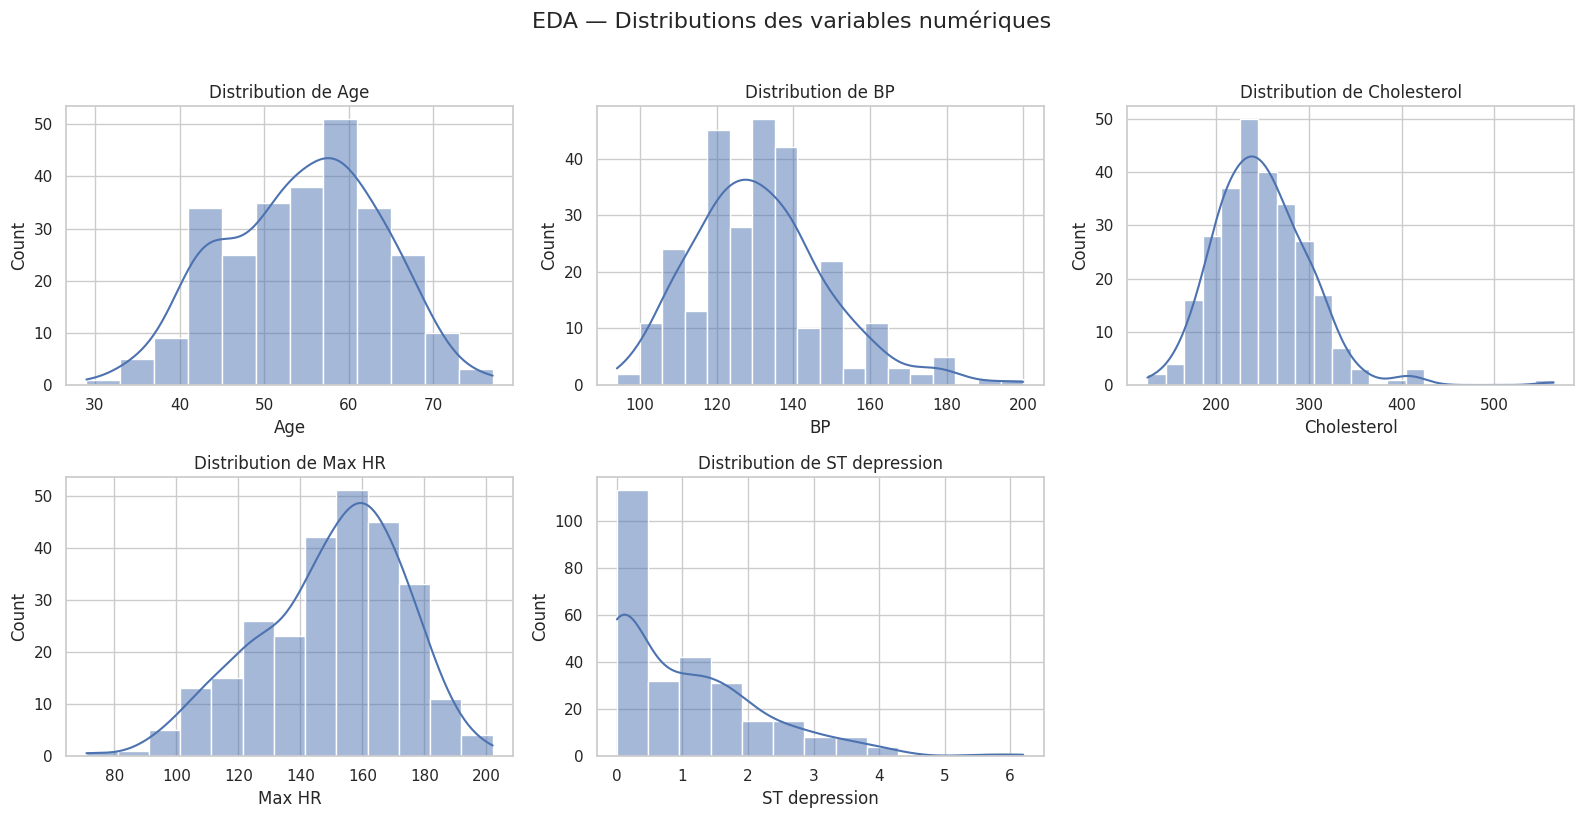

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(df_model[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("EDA — Distributions des variables numériques", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

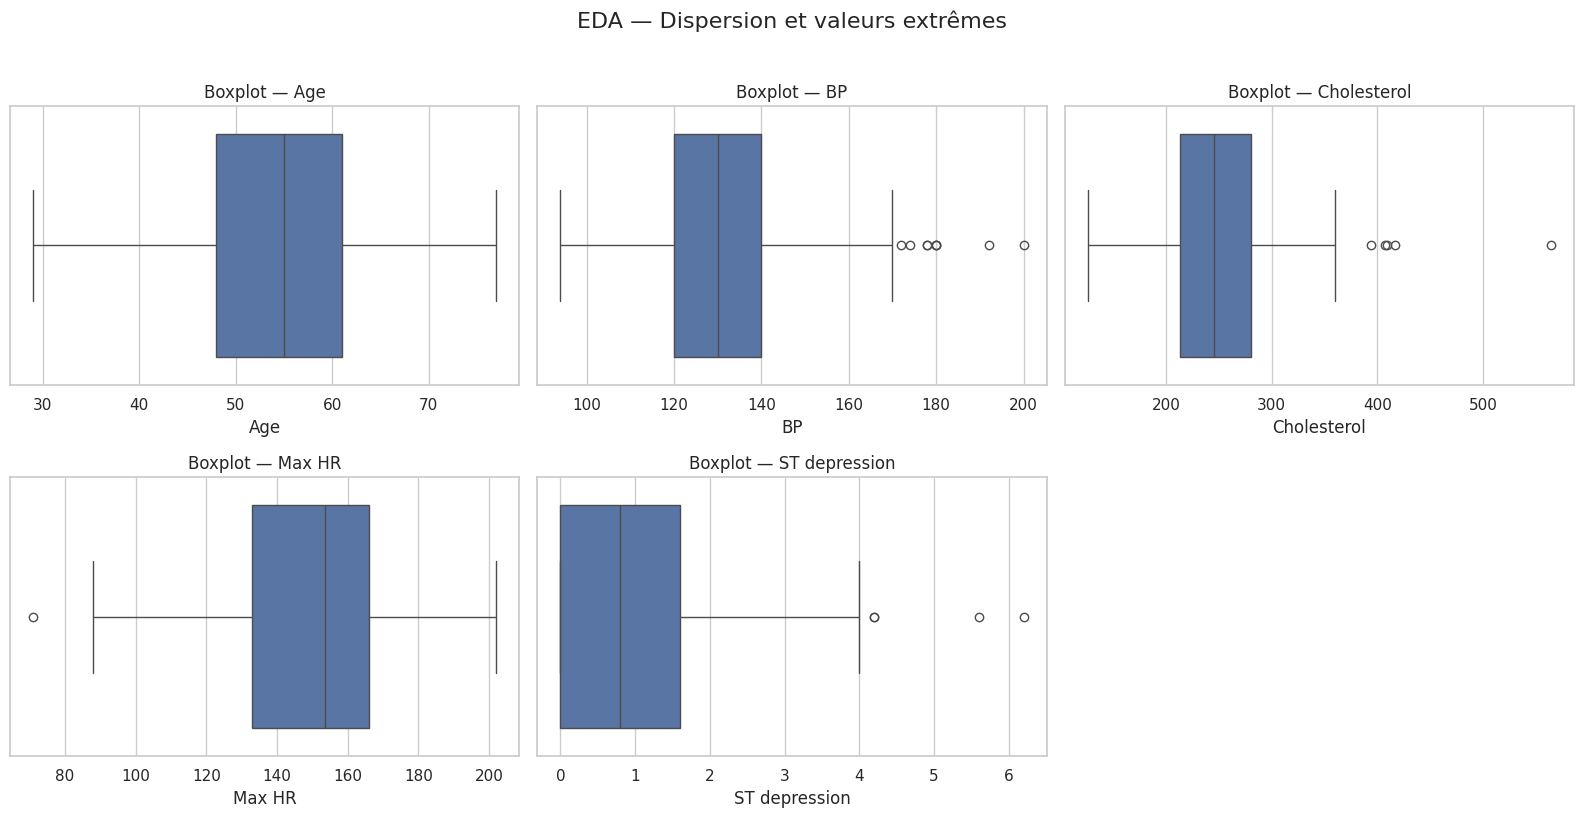

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(x=df_model[col], ax=axes[i])
    axes[i].set_title(f"Boxplot — {col}")
    axes[i].set_xlabel(col)

for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("EDA — Dispersion et valeurs extrêmes", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Interprétation

Les distributions numériques montrent des profils assez contrastés selon les variables. Age présente une répartition relativement régulière, centrée autour de 50–60 ans, sans asymétrie extrême. BP est davantage concentrée entre 110 et 145, avec quelques valeurs plus élevées qui traduisent une légère asymétrie à droite.

Cholesterol est plus dispersée, avec plusieurs valeurs élevées qui s’éloignent nettement du cœur de la distribution. Max HR apparaît plus concentrée, avec un pic autour de 150–170, ce qui en fait une variable potentiellement plus stable pour la modélisation. Enfin, ST depression présente la distribution la plus dissymétrique, avec une forte concentration sur les faibles valeurs et une longue traîne vers les niveaux élevés.

Dans l’ensemble, cette lecture confirme la nécessité d’un prétraitement adapté des variables numériques, notamment via la standardisation. Elle montre aussi que certaines variables, comme Cholesterol et surtout ST depression, devront être interprétées avec prudence en raison de leur dispersion et de la présence de valeurs extrêmes.

## 6. Analyse univariée des variables catégorielles

Comprendre :
- comprendre la répartition des modalités ;
- repérer des catégories rares ;
- vérifier que leur traitement en one-hot encoding est justifié.

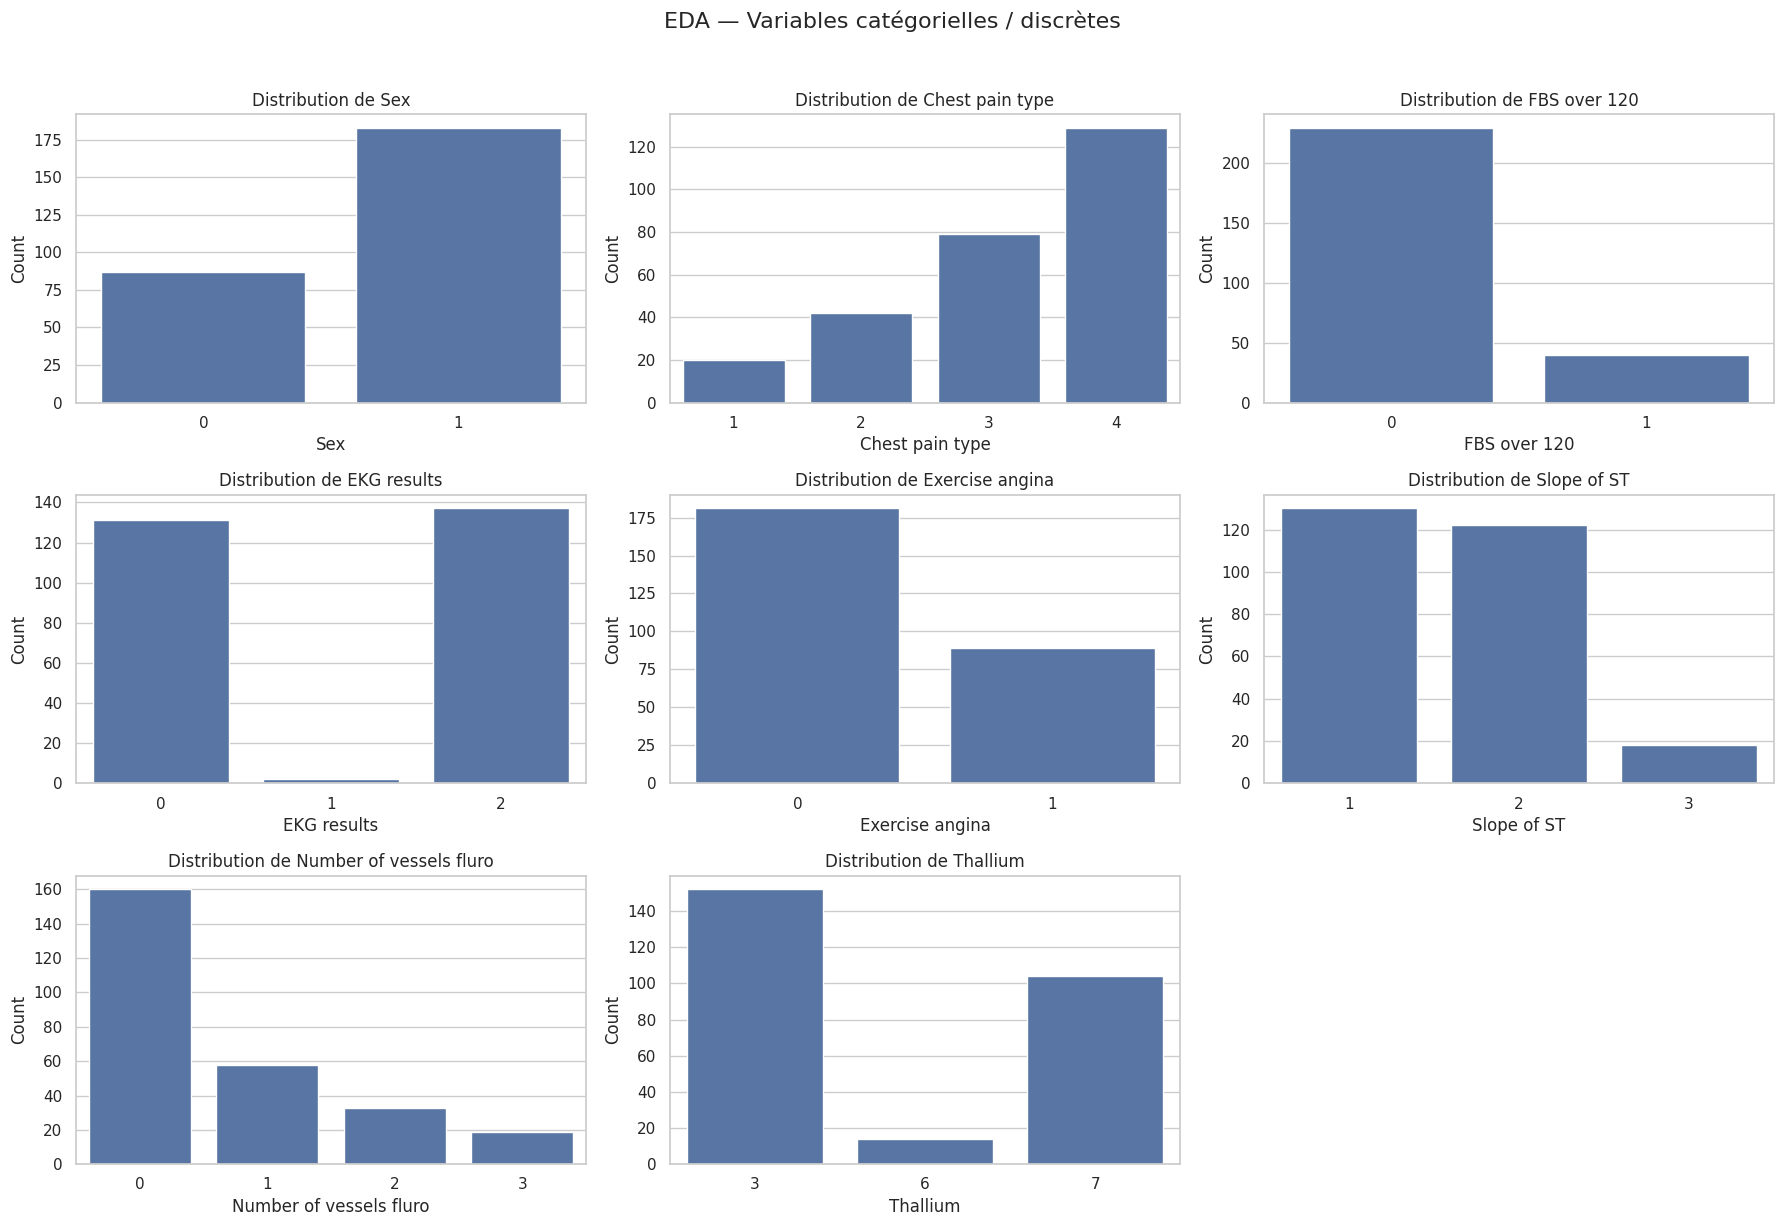

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    order = sorted(df_model[col].dropna().unique())
    sns.countplot(data=df_model, x=col, order=order, ax=axes[i])
    axes[i].set_title(f"Distribution de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("EDA — Variables catégorielles / discrètes", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Interprétation

Les variables catégorielles présentent des répartitions parfois très déséquilibrées selon les modalités. Sex = 1 est nettement plus représenté que Sex = 0, FBS over 120 = 0 domine largement, et Number of vessels fluro = 0 concentre la majorité des observations. À l’inverse, certaines modalités apparaissent beaucoup plus rares, notamment pour EKG results, Slope of ST et Thallium.

Ces résultats confirment que ces variables doivent être traitées comme des catégories distinctes et non comme des variables numériques continues. Ils montrent aussi que certaines modalités rares devront être interprétées avec prudence, car leur faible effectif peut limiter la robustesse des conclusions tirées du modèle.

## 7. Analyse bivariée : relation entre les variables et la cible

Identifier les variables les plus susceptibles de contribuer à la détection du risque cardiaque.

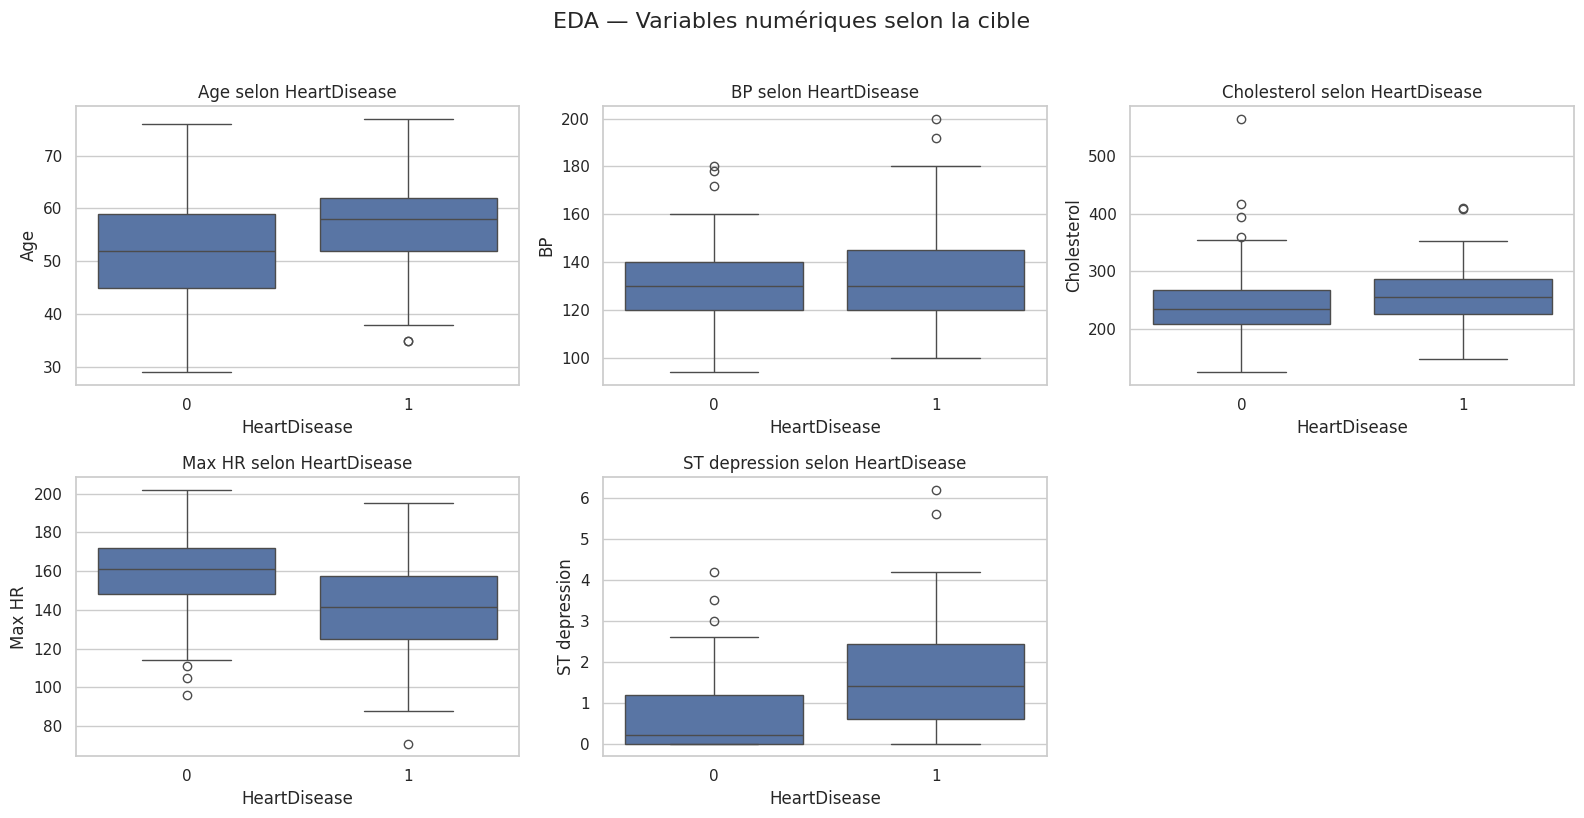

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(data=df_model, x="HeartDisease", y=col, ax=axes[i])
    axes[i].set_title(f"{col} selon HeartDisease")
    axes[i].set_xlabel("HeartDisease")
    axes[i].set_ylabel(col)

for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("EDA — Variables numériques selon la cible", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
comparison_numeric = (
    df_model.groupby("HeartDisease")[numeric_features]
    .agg(["mean", "median"])
    .T
)

comparison_numeric

HeartDisease               0       1
Age           mean    52.707  56.592
              median  52.000  58.000
BP            mean   128.867 134.442
              median 130.000 130.000
Cholesterol   mean   244.213 256.467
              median 236.000 255.500
Max HR        mean   158.333 138.858
              median 161.000 141.500
ST depression mean     0.623   1.584
              median   0.200   1.400

Les boxplots suggèrent que certaines variables numériques distinguent assez bien les deux groupes. Les patients avec HeartDisease = 1 semblent en moyenne plus âgés, avec un cholestérol légèrement plus élevé et surtout une ST depression nettement supérieure, ce qui en fait une variable potentiellement très discriminante.

À l’inverse, Max HR paraît plus faible chez les patients atteints, ce qui suggère également un signal utile pour la modélisation. BP montre en revanche un recouvrement plus important entre les deux groupes, ce qui laisse penser qu’elle est moins discriminante prise isolément.

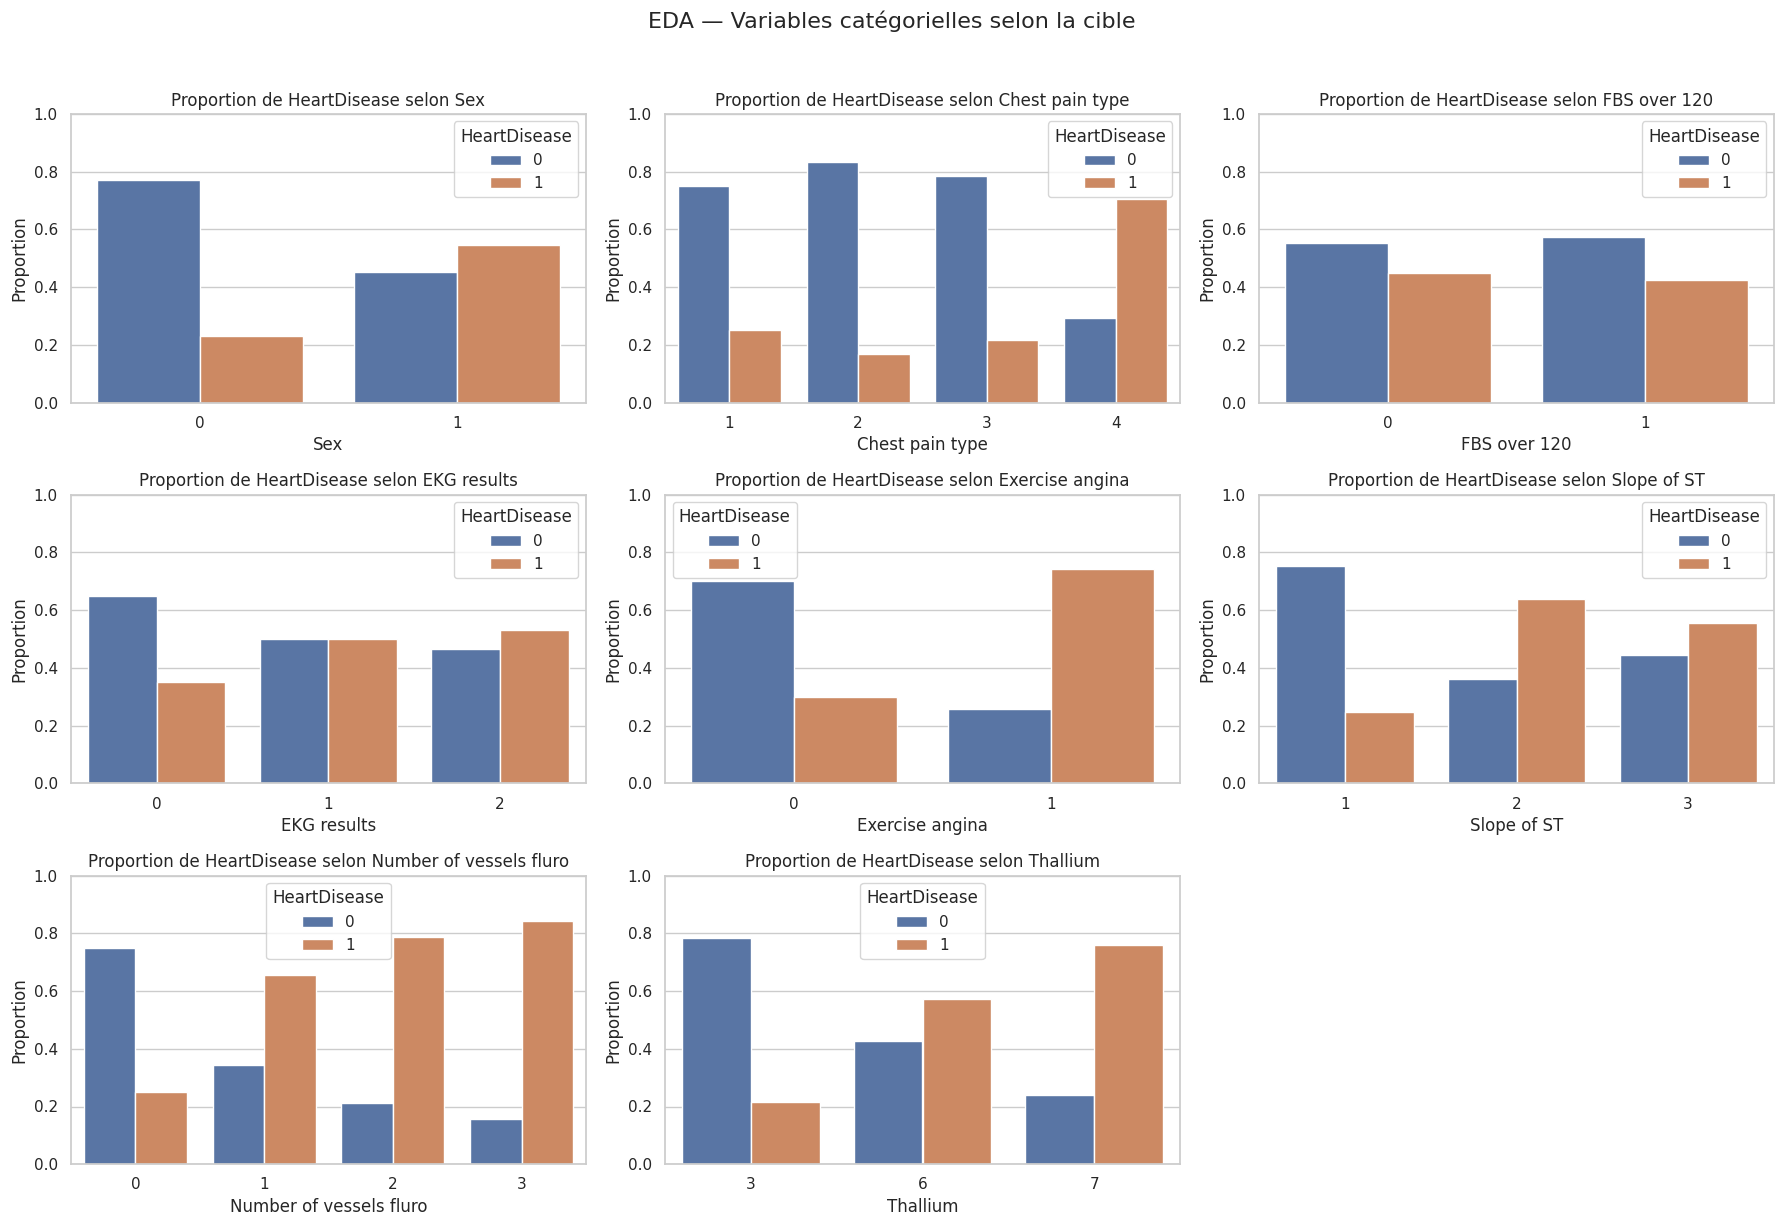

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    prop_df = (
        pd.crosstab(df_model[col], df_model["HeartDisease"], normalize="index")
        .reset_index()
        .melt(id_vars=col, var_name="HeartDisease", value_name="proportion")
    )

    sns.barplot(
        data=prop_df,
        x=col,
        y="proportion",
        hue="HeartDisease",
        ax=axes[i]
    )
    axes[i].set_title(f"Proportion de HeartDisease selon {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Proportion")
    axes[i].set_ylim(0, 1)

for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("EDA — Variables catégorielles selon la cible", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Les variables catégorielles montrent que certaines modalités sont clairement plus associées à la présence de maladie cardiaque que d’autres. Les écarts semblent particulièrement marqués pour Chest pain type, Exercise angina, Slope of ST, Number of vessels fluro et Thallium, ce qui suggère un pouvoir discriminant intéressant pour la modélisation.

À l’inverse, FBS over 120 paraît moins différencier les deux groupes, avec des proportions assez proches. Globalement, ces résultats confirment que plusieurs variables catégorielles apportent un signal utile, mais avec une intensité variable selon les modalités.

## 8. Corrélations entre variables numériques


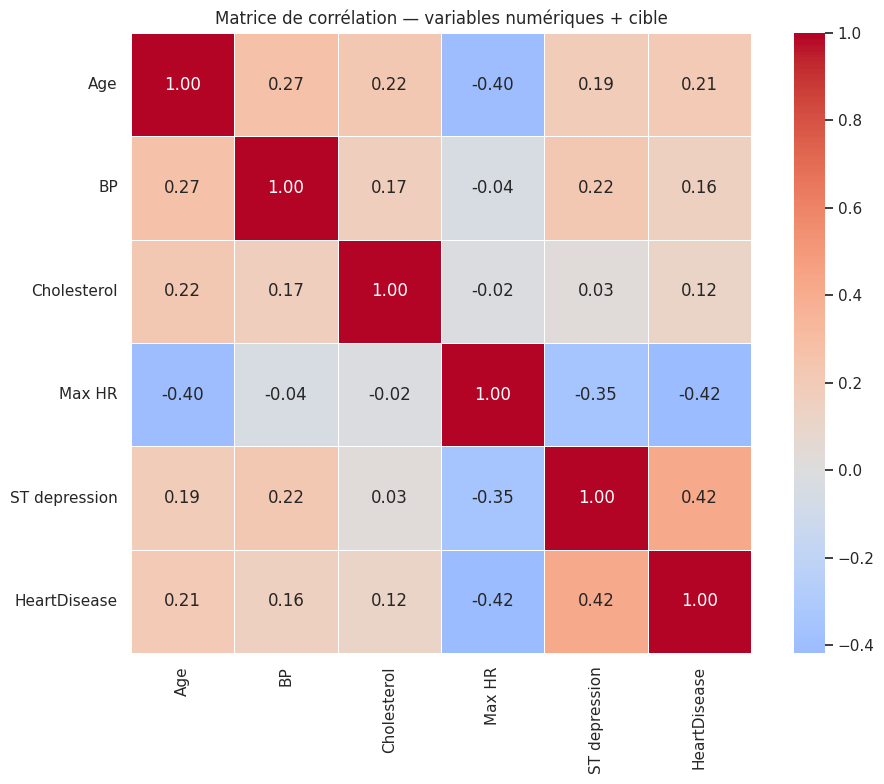

In [16]:
plt.figure(figsize=(10, 8))

corr = df_model[numeric_features + ["HeartDisease"]].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Matrice de corrélation — variables numériques + cible")
plt.tight_layout()
plt.show()

### Corrélations et redondance potentielle

La matrice de corrélation montre que les relations entre variables numériques restent globalement modérées, ce qui limite le risque de forte redondance. Les deux liens les plus marqués avec la cible sont ST depression (corrélation positive de 0,42) et Max HR (corrélation négative de -0,42). À l’inverse, Age, BP et surtout Cholesterol présentent des corrélations plus faibles avec la cible, ce qui suggère un signal plus limité pris isolément.

## 9. Synthèse de l’analyse exploratoire

L’analyse exploratoire met en évidence plusieurs enseignements utiles pour la suite du projet. Du côté des variables numériques, ST depression et Max HR apparaissent comme les signaux les plus marqués : la première est positivement associée à la présence de maladie cardiaque, tandis que la seconde présente une relation inverse. Age montre également un effet visible, avec des patients atteints globalement plus âgés. À l’inverse, BP et Cholesterol semblent apporter un signal plus modéré lorsqu’ils sont considérés isolément.

Les variables catégorielles confirment aussi la présence de différences nettes entre groupes. Les écarts les plus visibles concernent Chest pain type, Exercise angina, Slope of ST, Number of vessels fluro et Thallium, qui paraissent particulièrement discriminantes. En revanche, FBS over 120 semble moins différencier les patients atteints des non atteints.

L’EDA montre également que le dataset combine des variables numériques et des variables catégorielles codées par des entiers, ce qui justifie un prétraitement différencié. Les distributions observées, notamment les asymétries de Cholesterol et ST depression ainsi que la présence de quelques valeurs extrêmes, renforcent l’intérêt d’un pipeline avec standardisation des variables numériques et encodage adapté des variables catégorielles.

Enfin, la matrice de corrélation suggère une redondance limitée entre les variables numériques, ce qui est plutôt favorable à l’utilisation d’une régression logistique interprétable. Globalement, l’analyse exploratoire confirme qu’un modèle simple et lisible est pertinent pour ce projet, avec une attention particulière portée aux variables les plus discriminantes et au compromis métier entre détection et fiabilité.



## 10. Séparation train / test


In [17]:
X = df_model.drop(columns=["HeartDisease"])
y = df_model["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("\nRépartition cible train :")
print(y_train.value_counts(normalize=True))
print("\nRépartition cible test :")
print(y_test.value_counts(normalize=True))

Train shape: (216, 13)
Test shape : (54, 13)

Répartition cible train :
HeartDisease
0   0.556
1   0.444
Name: proportion, dtype: float64

Répartition cible test :
HeartDisease
0   0.556
1   0.444
Name: proportion, dtype: float64


## 11. Prétraitement des données

Le preprocessing a été conçu pour respecter la nature des variables. Les variables numériques sont imputées puis standardisées, tandis que les variables catégorielles sont imputées puis encodées en one-hot encoding. Cette distinction est essentielle pour éviter de traiter comme continues des variables qui représentent en réalité des catégories cliniques distinctes.

Le preprocessing est construit dans un pipeline unique :
- imputation médiane + standardisation pour les variables numériques ;
- imputation mode + one-hot encoding pour les variables catégorielles.

L’encodage avec `drop="first"` facilite l’interprétation des coefficients en évitant une redondance inutile.

In [18]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

## 12. Modélisation — régression logistique

In [19]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

cv_results_df = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "mean_cv_score": [
        cv_scores["test_accuracy"].mean(),
        cv_scores["test_precision"].mean(),
        cv_scores["test_recall"].mean(),
        cv_scores["test_f1"].mean(),
        cv_scores["test_roc_auc"].mean()
    ],
    "std_cv_score": [
        cv_scores["test_accuracy"].std(),
        cv_scores["test_precision"].std(),
        cv_scores["test_recall"].std(),
        cv_scores["test_f1"].std(),
        cv_scores["test_roc_auc"].std()
    ]
})

cv_results_df

,metric,mean_cv_score,std_cv_score
0,accuracy,0.833,0.050
1,precision,0.829,0.072
2,recall,0.792,0.075
3,f1,0.808,0.060
4,roc_auc,0.907,0.039


La validation croisée montre que la régression logistique obtient des performances globalement solides et relativement stables sur les différents sous-échantillons d’entraînement. L’accuracy moyenne de 0,833 et le F1-score de 0,808 indiquent un bon équilibre global entre détection et fiabilité.

Le recall moyen de 0,792 est particulièrement important dans le cadre de ce projet, car il mesure la capacité du modèle à identifier les patients réellement à risque. La precision de 0,829 suggère en parallèle que les prédictions positives restent globalement fiables. Enfin, le ROC AUC de 0,907 confirme une bonne capacité du modèle à distinguer les deux classes.

Les écarts-types restent modérés sur l’ensemble des métriques, ce qui est plutôt rassurant malgré la taille limitée du dataset. Cela suggère que le modèle n’est pas seulement performant sur une seule partition, mais qu’il présente une robustesse satisfaisante en validation croisée.

## 13. Évaluation finale sur le jeu de test

Le modèle est maintenant entraîné sur l’ensemble du train puis évalué une seule fois sur le test set.  
Cette étape fournit l’estimation finale de performance.

In [20]:
logistic_pipeline.fit(X_train, y_train)

y_pred = logistic_pipeline.predict(X_test)
y_proba = logistic_pipeline.predict_proba(X_test)[:, 1]

test_metrics_df = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "test_score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba)
    ]
})

test_metrics_df

,metric,test_score
0,accuracy,0.870
1,precision,0.815
2,recall,0.917
3,f1,0.863
4,roc_auc,0.911


Les résultats sur le jeu de test confirment les bonnes performances observées en validation croisée. Le modèle atteint une accuracy de 0,870 et un F1-score de 0,863, ce qui traduit un bon équilibre global entre détection des cas à risque et fiabilité des prédictions. Le point le plus important ici est le recall de 0,917, qui montre que le modèle identifie une grande majorité des patients réellement atteints. Dans le cadre de ce projet, c’est un résultat particulièrement intéressant, car il limite le risque de faux négatifs. La precision de 0,815 reste également satisfaisante, ce qui signifie que les prédictions positives conservent une bonne crédibilité malgré cette priorité donnée à la détection. Enfin, le ROC AUC de 0,911 confirme une bonne capacité de discrimination entre les deux classes.

              precision    recall  f1-score   support

           0       0.93      0.83      0.88        30
           1       0.81      0.92      0.86        24

    accuracy                           0.87        54
   macro avg       0.87      0.88      0.87        54
weighted avg       0.88      0.87      0.87        54



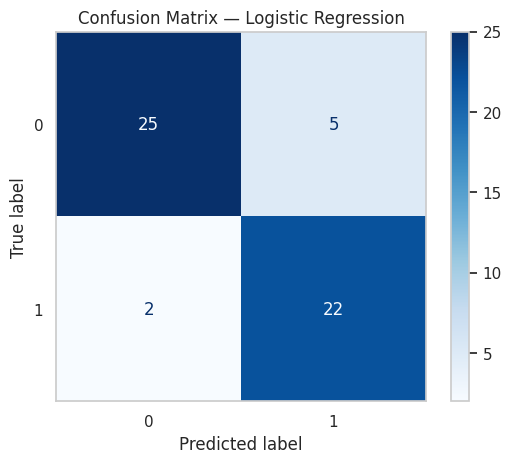

In [21]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression")
plt.grid(False)
plt.show()

La matrice de confusion montre que le modèle classe correctement 47 observations sur 54, ce qui confirme une performance globale solide sur le jeu de test. Il identifie correctement 25 vrais négatifs et 22 vrais positifs, ce qui traduit une bonne capacité à distinguer les deux classes.

Le point le plus important est le faible nombre de faux négatifs (2), c’est-à-dire les patients à risque non détectés. Dans le cadre de ce projet, c’est un résultat particulièrement intéressant, car l’objectif métier est justement de limiter ce type d’erreur. Le modèle produit en revanche 5 faux positifs, ce qui reste acceptable dans une logique de dépistage, où il est souvent préférable de surdétecter légèrement plutôt que de manquer des cas réels.

## 14. Analyse du seuil de décision

L’analyse du seuil de décision permet d’adapter la classification à l’objectif métier. Le seuil par défaut de 0,5 n’est pas nécessairement optimal : dans un contexte de dépistage, il peut être pertinent d’abaisser ce seuil afin d’augmenter le recall et de limiter les faux négatifs, même si cela conduit à davantage de faux positifs.

In [22]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    
    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,accuracy,precision,recall,f1
0,0.300,0.796,0.697,0.958,0.807
1,0.400,0.815,0.733,0.917,0.815
2,0.500,0.870,0.815,0.917,0.863
3,0.600,0.870,0.840,0.875,0.857
4,0.700,0.833,0.826,0.792,0.809


L’analyse des seuils montre qu’abaisser fortement le seuil améliore le recall, mais au prix d’une baisse de la precision et de l’accuracy. À l’inverse, des seuils plus élevés rendent le modèle plus conservateur, mais augmentent le risque de faux négatifs.

Dans ce projet, le seuil de 0,5 apparaît comme le meilleur compromis entre détection des patients à risque et fiabilité des prédictions. Il conserve un recall élevé tout en offrant les meilleures performances globales sur le jeu de test.

## 15. Interprétation des coefficients

In [23]:
model = logistic_pipeline.named_steps["model"]
preprocessor_fitted = logistic_pipeline.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": model.coef_[0]
})

coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df["feature_clean"] = (
    coef_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

coef_df = coef_df.sort_values("coefficient", ascending=False)

coef_df.head(15)

,feature,coefficient,odds_ratio,abs_coefficient,feature_clean
17,cat__Number of vessels fluro_3,1.531,4.622,1.531,Number of vessels fluro_3
8,cat__Chest pain type_4,1.491,4.440,1.491,Chest pain type_4
5,cat__Sex_1,1.436,4.204,1.436,Sex_1
15,cat__Number of vessels fluro_1,1.280,3.596,1.280,Number of vessels fluro_1
16,cat__Number of vessels fluro_2,1.192,3.292,1.192,Number of vessels fluro_2
19,cat__Thallium_7,1.156,3.177,1.156,Thallium_7
13,cat__Slope of ST_2,0.902,2.464,0.902,Slope of ST_2
12,cat__Exercise angina_1,0.557,1.745,0.557,Exercise angina_1
4,num__ST depression,0.415,1.514,0.415,ST depression
1,num__BP,0.280,1.324,0.280,BP


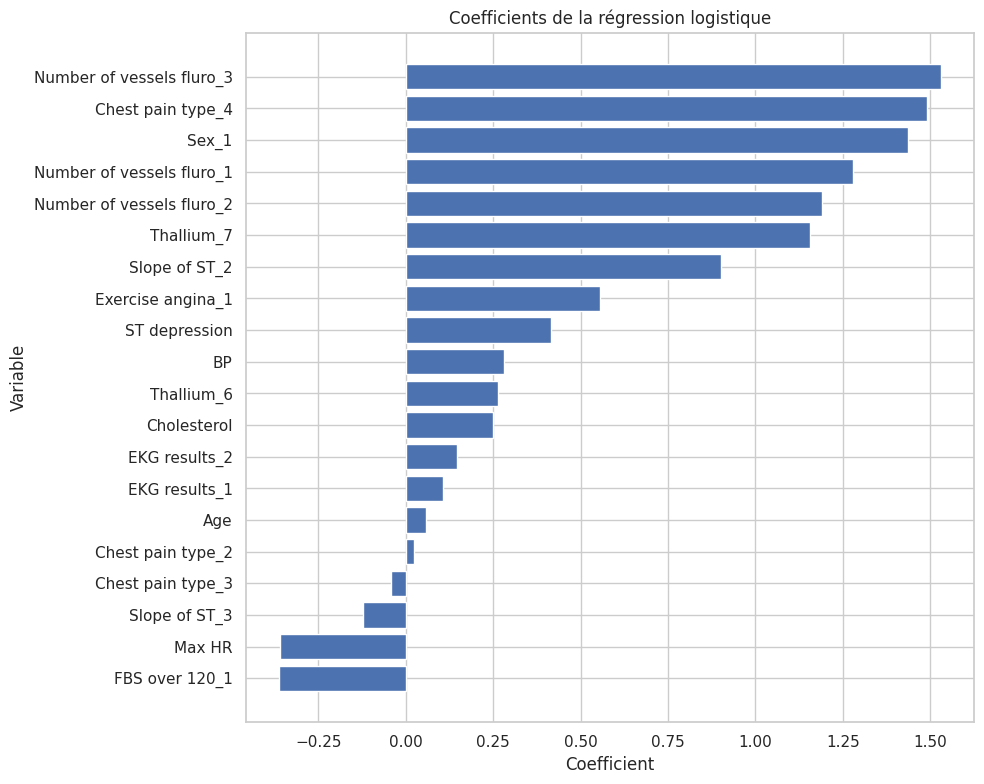

In [24]:
coef_plot = coef_df.sort_values(by="coefficient")

plt.figure(figsize=(10, 8))
plt.barh(coef_plot["feature_clean"], coef_plot["coefficient"])
plt.title("Coefficients de la régression logistique")
plt.xlabel("Coefficient")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

Les coefficients montrent que plusieurs variables sont fortement associées à une hausse de la probabilité prédite de maladie cardiaque. Les effets positifs les plus marqués concernent notamment Number of vessels fluro_3, Chest pain type_4, Sex_1, Thallium_7 et certaines modalités de Slope of ST et Exercise angina. Cela suggère que ces caractéristiques jouent un rôle important dans la prédiction du risque au sein de ce dataset.

À l’inverse, Max HR présente un coefficient négatif relativement marqué, ce qui indique qu’une fréquence cardiaque maximale plus élevée est associée à une probabilité prédite plus faible de maladie cardiaque. FBS over 120_1 montre également un effet négatif dans ce modèle, mais ce résultat doit être interprété avec plus de prudence, surtout si la variable apparaissait peu discriminante dans l’EDA.

Globalement, ce graphique confirme que le modèle s’appuie surtout sur un petit groupe de variables particulièrement informatives. Il faut toutefois rappeler que les variables catégorielles encodées s’interprètent par rapport à une catégorie de référence, et que ces coefficients traduisent des associations statistiques plutôt que des relations causales.

## 16. Conclusion métier

Ce projet avait pour objectif d’analyser les facteurs associés au risque de maladie cardiaque et de construire un modèle simple, interprétable et cohérent avec une logique d’aide à la décision. L’analyse exploratoire a permis d’identifier plusieurs variables particulièrement informatives, notamment ST depression, Max HR, ainsi que certaines caractéristiques catégorielles comme Chest pain type, Exercise angina, Number of vessels fluro et Thallium. Ces résultats montrent que le risque ne repose pas sur un seul indicateur, mais sur une combinaison de signaux cliniques qu’il est pertinent d’analyser conjointement.

La régression logistique apparaît ici comme un choix pertinent. Elle offre un bon compromis entre performance, simplicité et interprétabilité, ce qui est essentiel dans un contexte où les résultats doivent pouvoir être compris et discutés par des profils non techniques. Les performances obtenues montrent que le modèle détecte correctement une grande majorité des patients à risque, ce qui répond bien à l’objectif principal du projet : limiter les faux négatifs.

L’analyse du seuil de décision confirme également qu’un modèle ne doit pas être évalué uniquement à travers une performance globale, mais aussi à travers le type d’erreurs qu’il produit. Dans une logique de dépistage, accepter un certain niveau de faux positifs peut être justifié si cela permet d’éviter de manquer des cas réellement à risque. Dans ce projet, le seuil par défaut de 0,5 apparaît comme le meilleur compromis entre détection et fiabilité des prédictions.

En pratique, ce type de modèle pourrait être envisagé comme un outil d’aide au triage ou à la priorisation, et non comme un outil de diagnostic autonome. Il pourrait servir à repérer plus rapidement les profils nécessitant une attention particulière ou des examens complémentaires. Le modèle met en évidence des associations statistiques utiles à la décision, mais ne remplace ni l’expertise clinique ni une validation sur des données plus larges.